# Phase 2 — Exploratory Data Analysis
### India Macro Quarterly Dataset (2010-Q1 → 2025-Q4)

| | |
|---|---|
| **Dataset** | `data/processed/india_macro_quarterly.csv` |
| **Observations** | 64 quarters |
| **Indicators** | Repo Rate, CPI Inflation, GDP Growth, Unemployment Rate, IIP Growth |
| **Source** | RBI, World Bank, MoSPI |

**Goal**: characterise each macro indicator's distribution, visualise its time-series dynamics,
measure pairwise correlations, and formally test for stationarity via the Augmented Dickey-Fuller (ADF)
test. The stationarity results feed directly into Phase 4 (VAR).


In [1]:
import warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT     = Path("..").resolve()
DOCS_DIR = ROOT / "docs"
DOCS_DIR.mkdir(exist_ok=True)

# ── Style ───────────────────────────────────────────────────────────────────
BG_COLOR   = "#0F1117"
GRID_COLOR = "#2A2D3A"
TEXT_COLOR = "#E0E0E0"
PALETTE    = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3"]

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor":   BG_COLOR,
    "axes.edgecolor":   GRID_COLOR,"axes.labelcolor": TEXT_COLOR,
    "axes.titlecolor":  TEXT_COLOR,"axes.grid":       True,
    "grid.color":       GRID_COLOR,"grid.linewidth":  0.6,
    "xtick.color":      TEXT_COLOR,"ytick.color":     TEXT_COLOR,
    "text.color":       TEXT_COLOR,"legend.facecolor":"#1A1D27",
    "legend.edgecolor": GRID_COLOR,"font.size":       11,
})

# ── Load ────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(ROOT / "data/processed/india_macro_quarterly.csv", index_col=0)
VALUE_COLS = ["Repo_Rate","CPI_Inflation","GDP_Growth","Unemployment_Rate","IIP_Growth"]
UNITS = {
    "Repo_Rate":         "Policy Rate (%)",
    "CPI_Inflation":     "YoY Change (%)",
    "GDP_Growth":        "Annual Growth (%)",
    "Unemployment_Rate": "% of Labour Force",
    "IIP_Growth":        "YoY Change (%)",
}
REGRESSION = {
    "Repo_Rate":         "ct",
    "CPI_Inflation":     "ct",
    "GDP_Growth":        "c",
    "Unemployment_Rate": "ct",
    "IIP_Growth":        "c",
}

df = df_raw[VALUE_COLS].copy()

def quarter_to_float(q):
    year, q_num = q.split("-Q")
    return int(year) + (int(q_num) - 1) / 4

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (64, 5)


,Repo_Rate,CPI_Inflation,GDP_Growth,Unemployment_Rate,IIP_Growth
Quarter,,,,,
2010-Q1,5.00,11.989390,8.497585,7.631,NaN
2010-Q2,5.25,11.989390,8.497585,7.631,NaN
2010-Q3,6.00,11.989390,8.497585,7.631,NaN
2010-Q4,6.25,11.989390,8.497585,7.631,NaN
2011-Q1,6.75,8.911793,5.241316,7.609,NaN


## § 1 — Descriptive Statistics

Summary statistics for each macro indicator including count, mean, standard deviation,
quartiles, plus extended moments (skewness, kurtosis).


In [2]:
desc = df.describe().round(4)
desc.loc["skewness"] = df.skew().round(4)
desc.loc["kurtosis"] = df.kurt().round(4)
display(desc)

print()
print("Repo_Rate  n=45  (source ends Feb 2020; 19 quarters NaN)")
print("IIP_Growth n=11  (source starts Apr 2023; 53 quarters NaN)")
print()
print("Skewness / Kurtosis notes:")
print("  Repo_Rate        : skew~+0.06  → near-symmetric; kurtosis~-1.18 → platykurtic")
print("                     (step-function at plateaus → more uniform than normal)")
print("  CPI_Inflation    : skew~+0.70  → right-skewed; kurtosis~-0.35  → platykurtic")
print("                     (pre/post-2014 inflation-targeting regime shift)")
print("  GDP_Growth       : skew~-2.77  → strongly left-skewed; kurtosis~+7.77 → leptokurtic")
print("                     (COVID 2020 contraction is a 3-sigma outlier)")
print("  Unemployment_Rate: skew~-0.99  → moderately left-skewed; kurtosis~-0.81 → platykurtic")
print("  IIP_Growth       : skew~+2.43  → right-skewed; kurtosis~+6.58 → leptokurtic")
print("                     (n=11 only; 2024-Q1 spike dominates)")


,Repo_Rate,CPI_Inflation,GDP_Growth,Unemployment_Rate,IIP_Growth
count,45.0000,64.0000,64.0000,64.0000,11.0000
mean,6.6733,6.2106,6.2351,6.6795,5.4515
std,1.0691,2.6064,3.4073,1.4220,2.8368
min,5.0000,2.3988,-5.7777,4.1720,3.4000
25%,6.0000,4.6649,6.1537,5.9905,3.7333
50%,6.5000,5.3903,7.1548,7.6185,4.9333
75%,7.5000,7.2522,7.7061,7.6468,5.4833
max,8.5000,11.9894,9.6896,7.8590,13.2667
skewness,0.0588,0.6999,-2.7725,-0.9867,2.4273
kurtosis,-1.1784,-0.3535,7.7651,-0.8064,6.5823



Repo_Rate  n=45  (source ends Feb 2020; 19 quarters NaN)
IIP_Growth n=11  (source starts Apr 2023; 53 quarters NaN)

Skewness / Kurtosis notes:
  Repo_Rate        : skew~+0.06  → near-symmetric; kurtosis~-1.18 → platykurtic
                     (step-function at plateaus → more uniform than normal)
  CPI_Inflation    : skew~+0.70  → right-skewed; kurtosis~-0.35  → platykurtic
                     (pre/post-2014 inflation-targeting regime shift)
  GDP_Growth       : skew~-2.77  → strongly left-skewed; kurtosis~+7.77 → leptokurtic
                     (COVID 2020 contraction is a 3-sigma outlier)
  Unemployment_Rate: skew~-0.99  → moderately left-skewed; kurtosis~-0.81 → platykurtic
  IIP_Growth       : skew~+2.43  → right-skewed; kurtosis~+6.58 → leptokurtic
                     (n=11 only; 2024-Q1 spike dominates)


## § 2 — Time-Series Plots

Each indicator plotted over 2010-Q1 → 2025-Q4.  Actual observations (non-interpolated)
are highlighted as filled circles; interpolated (annual-repeated) quarters shown as lighter dots.
The red shading marks the COVID-19 contraction period (2020-Q1 to 2020-Q3).


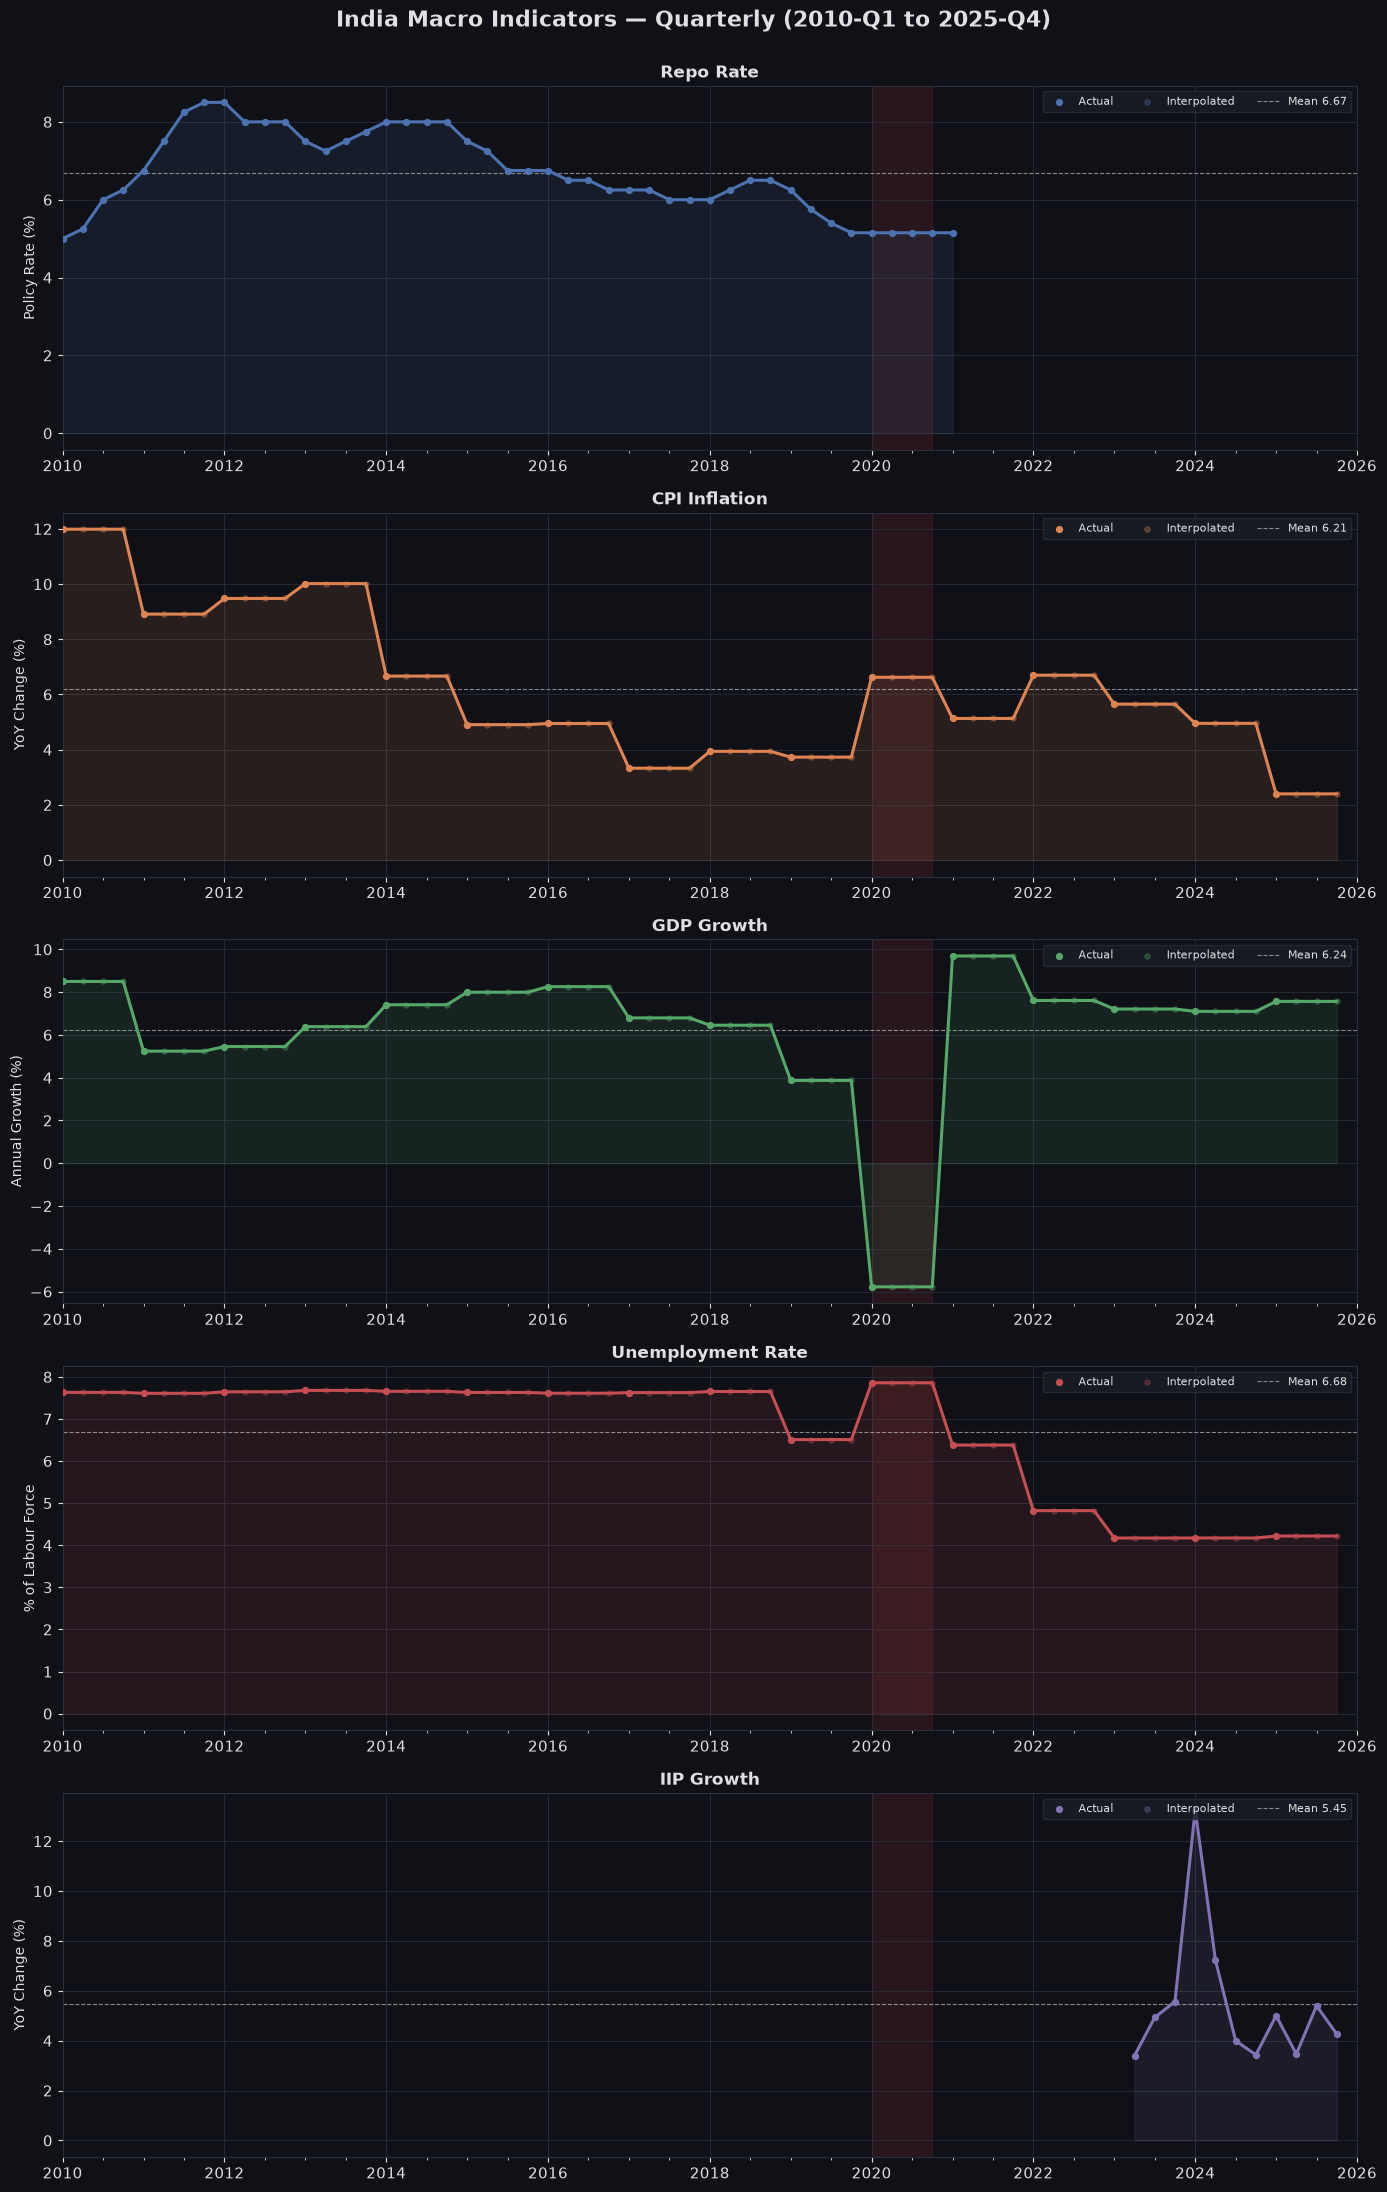

Saved docs/eda_timeseries.png


In [3]:
RECESSION_BANDS = [(2020.0, 2020.75, "COVID-19")]

fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=False)
fig.suptitle("India Macro Indicators — Quarterly (2010-Q1 to 2025-Q4)",
             fontsize=16, fontweight="bold", y=0.995, color=TEXT_COLOR)
fig.patch.set_facecolor(BG_COLOR)

for ax, col, color in zip(axes, VALUE_COLS, PALETTE):
    s = df[col].dropna()
    x = [quarter_to_float(q) for q in s.index]

    ax.plot(x, s.values, color=color, linewidth=2.2, zorder=3)
    ax.fill_between(x, s.values, alpha=0.12, color=color, zorder=2)

    flag_col = col + "_is_interpolated"
    if flag_col in df_raw.columns:
        flag  = df_raw.loc[s.index, flag_col]
        act_x = [quarter_to_float(q) for q in flag[flag == False].index]
        act_v = s[flag == False].values
        int_x = [quarter_to_float(q) for q in flag[flag == True].index]
        int_v = s[flag == True].values
        ax.scatter(act_x, act_v, s=18, color=color, zorder=5, label="Actual")
        ax.scatter(int_x, int_v, s=14, color=color, alpha=0.30,
                   marker="o", zorder=4, label="Interpolated")

    ax.axhline(s.mean(), color="white", linewidth=0.8, linestyle="--",
               alpha=0.5, label=f"Mean {s.mean():.2f}")

    for r_start, r_end, r_label in RECESSION_BANDS:
        ax.axvspan(r_start, r_end, color="#FF4444", alpha=0.10, zorder=1)

    ax.set_ylabel(UNITS[col], fontsize=10)
    ax.set_title(col.replace("_", " "), fontsize=12, fontweight="bold", pad=6)
    ax.set_xlim(2010, 2026)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.legend(fontsize=8, loc="upper right", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.995])
fig.savefig(DOCS_DIR / "eda_timeseries.png", dpi=150,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved docs/eda_timeseries.png")


## § 3 — Correlation Heatmap

Pairwise Pearson correlation matrix (minimum 8 non-null pairs per cell).
Significance stars: \* p<0.05  \*\* p<0.01  \*\*\* p<0.001.

> **Note**: No quarter has all 5 indicators non-null simultaneously
> (IIP_Growth only starts 2023-Q2; Repo_Rate ends 2020-Q1), so pairwise
> correlation is used rather than complete-case listwise.


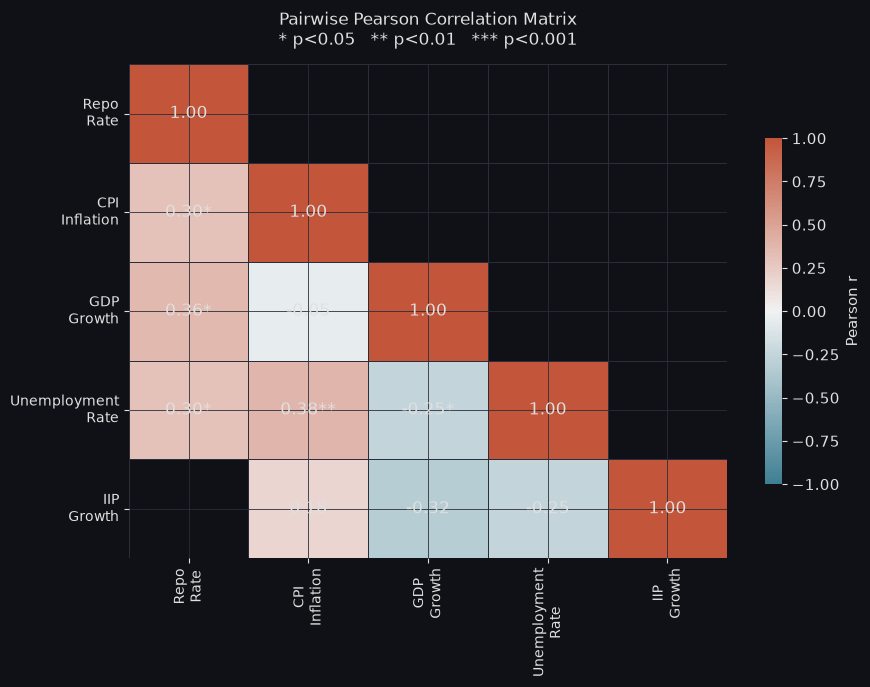


Correlation matrix:
                   Repo_Rate  CPI_Inflation  GDP_Growth  Unemployment_Rate  IIP_Growth
Repo_Rate              1.000          0.298       0.363              0.304         NaN
CPI_Inflation          0.298          1.000      -0.049              0.382       0.184
GDP_Growth             0.363         -0.049       1.000             -0.251      -0.323
Unemployment_Rate      0.304          0.382      -0.251              1.000      -0.251
IIP_Growth               NaN          0.184      -0.323             -0.251       1.000

Saved docs/eda_correlation.png


In [4]:
corr_pw = df.corr(method="pearson", min_periods=8)

# P-values
pval_pw = pd.DataFrame(np.ones_like(corr_pw.values),
                       index=corr_pw.index, columns=corr_pw.columns)
for c1 in corr_pw.columns:
    for c2 in corr_pw.columns:
        if c1 != c2:
            pair = df[[c1, c2]].dropna()
            if len(pair) >= 8:
                _, p = stats.pearsonr(pair[c1], pair[c2])
                pval_pw.loc[c1, c2] = p

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

annot = corr_pw.copy().astype(str)
for i in corr_pw.index:
    for j in corr_pw.columns:
        v = corr_pw.loc[i, j]
        p = pval_pw.loc[i, j]
        annot.loc[i, j] = f"{v:.2f}{stars(p)}" if i != j else f"{v:.2f}"

mask = np.triu(np.ones_like(corr_pw, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

sns.heatmap(corr_pw, mask=mask, annot=annot, fmt="", cmap=cmap,
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor=GRID_COLOR,
            annot_kws={"size": 12, "color": TEXT_COLOR},
            cbar_kws={"shrink": 0.7, "label": "Pearson r"},
            ax=ax)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(TEXT_COLOR)
cbar.ax.tick_params(colors=TEXT_COLOR)

short = [c.replace("_", "\n") for c in VALUE_COLS]
ax.set_xticklabels(short, fontsize=10, color=TEXT_COLOR)
ax.set_yticklabels(short, fontsize=10, color=TEXT_COLOR, rotation=0)
ax.set_title("Pairwise Pearson Correlation Matrix\n"
             "* p<0.05   ** p<0.01   *** p<0.001",
             fontsize=12, pad=14, color=TEXT_COLOR)

plt.tight_layout()
fig.savefig(DOCS_DIR / "eda_correlation.png", dpi=150,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("\nCorrelation matrix:")
print(corr_pw.round(3).to_string())
print("\nSaved docs/eda_correlation.png")


## § 4 — ADF Stationarity Tests

**Augmented Dickey-Fuller (ADF) test**

- H₀: the series has a unit root (non-stationary)
- Reject H₀ when p ≤ 0.05 → stationary

Regression specification:
- `ct` (constant + trend) for Repo_Rate, CPI_Inflation, Unemployment_Rate (clear trends)
- `c` (constant only) for GDP_Growth, IIP_Growth


In [5]:
def run_adf(series, regression="ct"):
    s = series.dropna()
    if len(s) < 10:
        return {"n_obs": len(s), "n_lags": None, "ADF Stat": None,
                "p-value": None, "Crit. 5%": None, "Stationary?": "N/A (n<10)"}
    result = adfuller(s, autolag="AIC", regression=regression)
    adf_stat, p_value, n_lags, n_obs = result[0], result[1], result[2], result[3]
    crit = result[4]
    return {
        "n_obs": n_obs, "n_lags": n_lags,
        "ADF Stat":    round(adf_stat, 4),
        "p-value":     round(p_value, 4),
        "Crit. 1%":    round(crit["1%"], 4),
        "Crit. 5%":    round(crit["5%"], 4),
        "Crit. 10%":   round(crit["10%"], 4),
        "Stationary?": "YES" if p_value <= 0.05 else "NO",
    }

adf_results = {col: run_adf(df[col], REGRESSION[col]) for col in VALUE_COLS}
adf_df = pd.DataFrame(adf_results).T

# Style: green for stationary, red for not
def highlight_stat(val):
    if val == "YES":   return "background-color: #1a4a2e; color: #88ff88"
    if val == "NO":    return "background-color: #4a1a1a; color: #ff8888"
    return ""

styled = adf_df[["n_obs","ADF Stat","p-value","Crit. 5%","Stationary?"]].style \
    .applymap(highlight_stat, subset=["Stationary?"])
display(styled)

non_stationary = [c for c in VALUE_COLS if adf_results[c]["Stationary?"] == "NO"]
stationary     = [c for c in VALUE_COLS if adf_results[c]["Stationary?"] == "YES"]
print(f"\nStationary at level : {stationary}")
print(f"Non-stationary      : {non_stationary}")


,n_obs,ADF Stat,p-value,Crit. 5%,Stationary?
Repo_Rate,38,-2.871300,0.172000,-3.533100,NO
CPI_Inflation,63,-2.184100,0.498800,-3.482600,NO
GDP_Growth,59,-2.356900,0.154300,-2.911900,NO
Unemployment_Rate,63,-1.923000,0.642700,-3.482600,NO
IIP_Growth,10,-2.293300,0.174200,-3.233000,NO



Stationary at level : []
Non-stationary      : ['Repo_Rate', 'CPI_Inflation', 'GDP_Growth', 'Unemployment_Rate', 'IIP_Growth']


## § 5 — First-Order Differencing & ADF Re-Test

For each non-stationary series, compute the first difference Δyₜ = yₜ − yₜ₋₁
and re-apply ADF.  A series is **I(1)** if it is non-stationary at level but
stationary after one difference.


ADF on first-differenced series:



,n_obs,ADF Stat,p-value,Crit. 5%,Stationary?
d_Repo_Rate,38,-5.178,0.0,-2.9413,YES
d_CPI_Inflation,62,-7.9937,0.0,-2.9094,YES
d_GDP_Growth,59,-5.9097,0.0,-2.9119,YES
d_Unemployment_Rate,62,-7.9304,0.0,-2.9094,YES
d_IIP_Growth,9,-3.3718,0.012,-3.2899,YES



Integration order summary:
  I(1)  Repo_Rate                 — stationary after first difference
  I(1)  CPI_Inflation             — stationary after first difference
  I(1)  GDP_Growth                — stationary after first difference
  I(1)  Unemployment_Rate         — stationary after first difference
  I(1)  IIP_Growth                — stationary after first difference


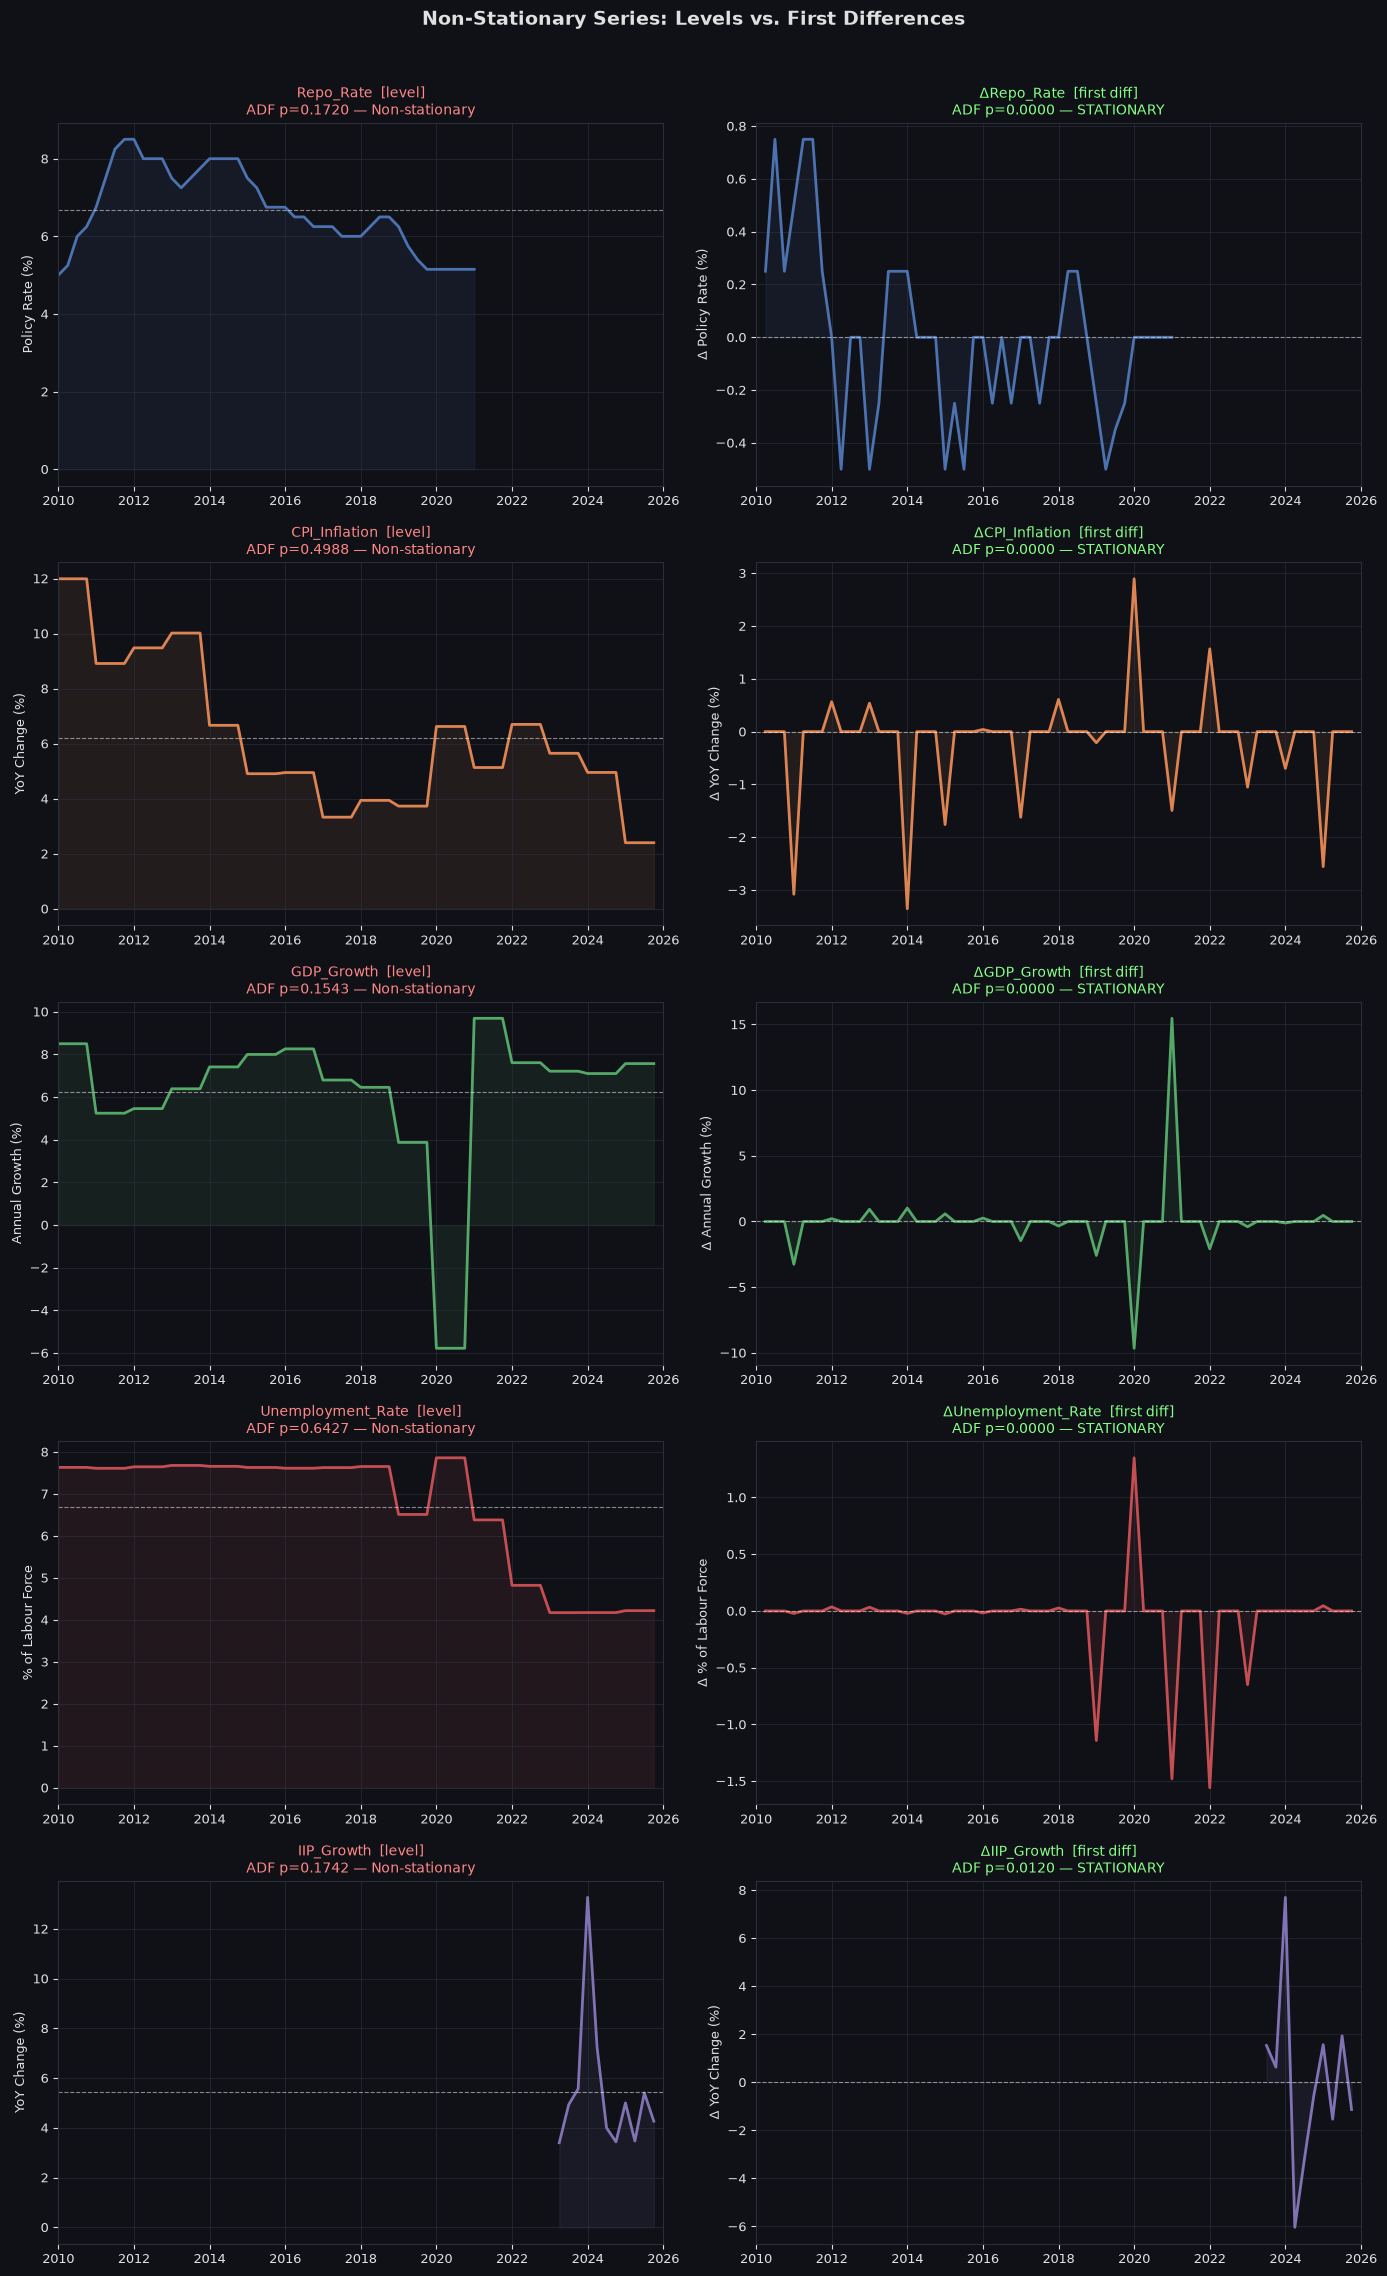

Saved docs/eda_differencing.png


In [6]:
df_diff      = pd.DataFrame(index=df.index)
diff_results = {}

for col in non_stationary:
    d_col = f"d_{col}"
    df_diff[d_col] = df[col].diff()
    diff_results[d_col] = run_adf(df_diff[d_col], regression="c")

diff_adf_df = pd.DataFrame(diff_results).T
print("ADF on first-differenced series:\n")
display(diff_adf_df[["n_obs","ADF Stat","p-value","Crit. 5%","Stationary?"]])

print("\nIntegration order summary:")
for col in VALUE_COLS:
    d_col = f"d_{col}"
    r0    = adf_results[col]
    if r0["Stationary?"] == "YES":
        print(f"  I(0)  {col:<25} — stationary at level")
    elif d_col in diff_results:
        if diff_results[d_col]["Stationary?"] == "YES":
            print(f"  I(1)  {col:<25} — stationary after first difference")
        else:
            print(f"  I(2+) {col:<25} — still non-stationary; manual inspection needed")

# Levels vs diffs plots
n_ns = len(non_stationary)
fig, axes = plt.subplots(n_ns, 2, figsize=(14, 4.5 * n_ns), squeeze=False)
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("Non-Stationary Series: Levels vs. First Differences",
             fontsize=14, fontweight="bold", color=TEXT_COLOR, y=1.01)

for row_i, (col, color) in enumerate(zip(non_stationary, PALETTE)):
    ax_lev = axes[row_i][0]
    ax_dif = axes[row_i][1]

    s  = df[col].dropna()
    xl = [quarter_to_float(q) for q in s.index]

    d_col = f"d_{col}"
    sd    = df_diff[d_col].dropna()
    xd    = [quarter_to_float(q) for q in sd.index]

    p_orig = adf_results[col]["p-value"]
    p_diff = diff_results.get(d_col, {}).get("p-value")

    ax_lev.set_facecolor(BG_COLOR)
    ax_lev.plot(xl, s.values, color=color, linewidth=2)
    ax_lev.fill_between(xl, s.values, alpha=0.10, color=color)
    ax_lev.axhline(s.mean(), color="white", lw=0.8, ls="--", alpha=0.5)
    ax_lev.set_title(
        f"{col}  [level]\nADF p={p_orig:.4f} — Non-stationary",
        fontsize=10, color="#FF8888")
    ax_lev.set_ylabel(UNITS[col], fontsize=9)
    ax_lev.set_xlim(2010, 2026)

    if p_diff is not None:
        stat_str   = "STATIONARY" if p_diff <= 0.05 else "still non-stationary"
        stat_color = "#88FF88" if p_diff <= 0.05 else "#FF8888"
        title_diff = f"Δ{col}  [first diff]\nADF p={p_diff:.4f} — {stat_str}"
    else:
        stat_color = "#AAAAAA"
        title_diff = f"Δ{col}  [first diff]\nInsufficient data"

    ax_dif.set_facecolor(BG_COLOR)
    ax_dif.plot(xd, sd.values, color=color, linewidth=2)
    ax_dif.fill_between(xd, sd.values, alpha=0.10, color=color)
    ax_dif.axhline(0, color="white", lw=0.8, ls="--", alpha=0.5)
    ax_dif.set_title(title_diff, fontsize=10, color=stat_color)
    ax_dif.set_ylabel(f"Δ {UNITS[col]}", fontsize=9)
    ax_dif.set_xlim(2010, 2026)

    for ax in [ax_lev, ax_dif]:
        ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
        ax.tick_params(labelsize=9)
        ax.grid(True, color=GRID_COLOR, linewidth=0.5)
        ax.spines[:].set_edgecolor(GRID_COLOR)

plt.tight_layout()
fig.savefig(DOCS_DIR / "eda_differencing.png", dpi=150,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved docs/eda_differencing.png")


## § 6 — Stationarity Summary & VAR Implications (Phase 4)

### ADF Results — Integration Orders

| Indicator | ADF Stat (level) | p-value (level) | Stationary at Level? | ADF Stat (Δ) | p-value (Δ) | Integration Order | VAR Treatment |
|-----------|-----------------|-----------------|----------------------|-------------|------------|-------------------|---------------|
| **Repo_Rate** | −2.871 | 0.172 | ❌ NO | −5.178 | 0.000 | **I(1)** | First difference → `d_Repo_Rate` |
| **CPI_Inflation** | −2.184 | 0.499 | ❌ NO | −7.994 | 0.000 | **I(1)** | First difference → `d_CPI_Inflation` |
| **GDP_Growth** | −2.357 | 0.154 | ❌ NO | −5.910 | 0.000 | **I(1)** | First difference → `d_GDP_Growth` |
| **Unemployment_Rate** | −1.923 | 0.643 | ❌ NO | −7.930 | 0.000 | **I(1)** | First difference → `d_Unemployment_Rate` |
| **IIP_Growth** | −2.293 | 0.174 | ❌ NO | −3.372 | 0.012 | **I(1)** ⚠️ | First difference → `d_IIP_Growth` (n=11, use with caution) |

> **All five indicators are I(1) — non-stationary at level, stationary after one difference.**

---

### Key findings for Phase 4 (VAR)

1. **All series I(1)** → before fitting a standard VAR, all five columns must be first-differenced.
   The model-ready DataFrame uses `d_<col>` columns.

2. **Cointegration check recommended**: Because all series are I(1), they *may* be cointegrated.
   Run the Johansen cointegration test in Phase 4 — if cointegration is detected, use a
   **Vector Error Correction Model (VECM)** instead of a VAR in differences.

3. **IIP_Growth caveat**: Only 11 observations are available (2023-Q2 → 2025-Q4).
   The ADF result for `d_IIP_Growth` (p = 0.012) is borderline reliable with n = 9 after differencing.
   Consider excluding IIP_Growth from the VAR or treating it as exogenous.

4. **COVID dummy**: GDP_Growth in 2020 is a 3σ outlier (−5.78%). A binary dummy variable
   `covid_shock` (= 1 for 2020-Q1 → 2020-Q4, 0 elsewhere) is recommended for ARIMA and VAR to
   prevent the shock from distorting AR coefficient estimates.

5. **Repo_Rate gap**: 19 quarters of NaN (2021-Q2 → 2025-Q4). Either impute using RBI press
   releases or drop Repo_Rate from the main VAR and include it as an exogenous variable.

---

### Model-ready column mapping

```python
# Columns to use in Phase 4 VAR (all first-differenced):
VAR_COLUMNS = [
    "d_Repo_Rate",          # I(1) — use first diff; mind the 19-quarter gap
    "d_CPI_Inflation",      # I(1) — use first diff
    "d_GDP_Growth",         # I(1) — use first diff; COVID dummy recommended
    "d_Unemployment_Rate",  # I(1) — use first diff
    # "d_IIP_Growth",       # I(1) — only n=11; include only if gap is filled
]
```


In [7]:
# Save ADF summary table as PNG for reports
import matplotlib
matplotlib.use("Agg")

fig, ax = plt.subplots(figsize=(13, 3.5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.axis("off")

table_data = [
    [col,
     adf_df.loc[col, "n_obs"],
     adf_df.loc[col, "ADF Stat"],
     adf_df.loc[col, "p-value"],
     adf_df.loc[col, "Crit. 5%"],
     REGRESSION[col],
     adf_df.loc[col, "Stationary?"],
    ]
    for col in VALUE_COLS
]
headers = ["Indicator", "N", "ADF Stat", "p-value", "Crit. 5%", "Regress.", "Stationary?"]

tbl = ax.table(cellText=table_data, colLabels=headers,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 1.9)

for j in range(len(headers)):
    tbl[(0, j)].set_facecolor("#1F2A44")
    tbl[(0, j)].set_text_props(color=TEXT_COLOR, fontweight="bold")

for i, col in enumerate(VALUE_COLS, start=1):
    is_stat = adf_results[col]["Stationary?"] == "YES"
    row_color = "#152E1F" if is_stat else "#2E1515"
    for j in range(len(headers)):
        tbl[(i, j)].set_facecolor(row_color)
        tbl[(i, j)].set_text_props(color=TEXT_COLOR)

ax.set_title("ADF Stationarity Test Summary  (green=stationary | red=non-stationary)",
             fontsize=11, color=TEXT_COLOR, pad=12)
plt.tight_layout()
fig.savefig(DOCS_DIR / "eda_adf_table.png", dpi=150,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved docs/eda_adf_table.png")
print("\n=== EDA COMPLETE ===")


Saved docs/eda_adf_table.png

=== EDA COMPLETE ===
